## Analisis de los clientes de tarjeta de crédito

<h3>Kevin Alexis Sotelo Guzmán</h3>

<h3>10/07/2026</h3>

<h3>Python</h3>


# 1. Ask

- Antecedentes:

El conjunto de datos Credit Card Customers contiene información demográfica, financiera y de comportamiento de más de 10,000 clientes de tarjetas de crédito de una institución bancaria. Su propósito es analizar los factores asociados con la pérdida de clientes (customer churn) y apoyar el desarrollo de modelos analíticos que permitan identificar a los clientes con mayor probabilidad de abandonar el servicio. El conjunto de datos incluye variables como edad, ingresos, nivel educativo, tipo de tarjeta, límite de crédito, actividad transaccional y estado del cliente.

- Problema de negocio:

La institución bancaria busca comprender por qué algunos clientes dejan de utilizar sus tarjetas de crédito. Identificar los factores que influyen en el abandono permitirá implementar estrategias de retención más efectivas, mejorar la satisfacción de los clientes y reducir las pérdidas económicas derivadas de la deserción.

- Objetivo general:

Analizar el comportamiento de los clientes de tarjetas de crédito para identificar los factores asociados con el abandono del servicio y generar recomendaciones estratégicas que contribuyan a mejorar la retención de clientes.

- Objetivos específicos:

Analizar las características demográficas y financieras de los clientes.

Identificar diferencias entre clientes activos y clientes que abandonaron el servicio.

Clasificar a los clientes según sus niveles de uso y comportamiento financiero.

Desarrollar recomendaciones de negocio orientadas a reducir la tasa de abandono de clientes.

- Preguntas de negocio:

1. ¿Cuáles son las características de los clientes que abandonan el servicio de tarjeta de crédito?

2. ¿Qué variables presentan mayor relación con el abandono de clientes?

3. ¿Qué segmentos de clientes presentan un mayor riesgo de abandono?

4. ¿Qué estrategias pueden implementarse para mejorar la retención de clientes a partir de los hallazgos del análisis?

# 2. Prepare

- Conjunto de datos:

La fuente de datos utilizada para este estudio de caso es el conjunto de datos Credit Card Customers. Este conjunto de datos se encuentra alojado en Kaggle y fue compartido por Sakshi Goyal. Contiene información sobre clientes de tarjetas de crédito de una institución bancaria, incluyendo características demográficas, financieras y de comportamiento.

- Accesibilidad y privacidad de los datos:

El conjunto de datos está disponible públicamente en Kaggle para fines educativos y de investigación. La información se encuentra anonimizada, lo que significa que no contiene datos personales que permitan identificar a los clientes. Esto permite utilizar el conjunto de datos para análisis y desarrollo de modelos sin comprometer la privacidad de los individuos.

- Organización y verificación de los datos:

El conjunto de datos consta de un archivo CSV denominado BankChurners.csv.

El archivo contiene una amplia variedad de información relacionada con los clientes de tarjetas de crédito, incluyendo:

Información demográfica, ingresos y nivel educativo, estado civil, tipo y categoría de la tarjeta de crédito, antigüedad como cliente del banco, límite de crédito, saldo pendiente y crédito disponible, número y monto de las transacciones realizadas, nivel de utilización del crédito, estado del cliente (cliente existente o cliente que abandonó el servicio).

Cada registro corresponde a un cliente y cada columna representa una característica específica utilizada para analizar su comportamiento y su probabilidad de abandono.

- Limitaciones de los datos:

Este conjunto de datos presenta varias limitaciones que pueden afectar los resultados del análisis, las principales limitaciones incluyen:

No se especifica el nombre de la institución financiera de la que provienen los datos.

No se proporciona información sobre el período exacto en que fueron recopilados los datos.

Los datos se encuentran completamente anonimizados, por lo que no es posible identificar a los clientes ni complementar el análisis con información externa.

Estas limitaciones deben tenerse en cuenta al interpretar los resultados y al desarrollar las conclusiones y recomendaciones derivadas del análisis.

# 3. Process

Herramientas: Python, pandas, numpy

Carga de las bibliotecas e importación de los datos:

In [1]:

import os
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


import kagglehub


/kaggle/input/datasets/sakshigoyal7/credit-card-customers/BankChurners.csv


Primero, importé el conjunto de datos ` BankChurners.csv.` utilizando la función `pd.read_csv()` de la biblioteca pandas.


In [2]:
# prepare the data

df = pd.read_csv('/kaggle/input/datasets/sakshigoyal7/credit-card-customers/BankChurners.csv')

Una vez cargado el conjunto de datos, verificaremos cuántas filas y columnas contiene utilizando el atributo .shape de pandas.

In [3]:
df.shape

(10127, 23)

Se puede observar que el conjunto de datos contiene 10,127 filas y 23 columnas. Ahora, verificaremos los nombres de las columnas utilizando el atributo .columns de la biblioteca pandas.

In [4]:
df.columns

Index(['CLIENTNUM', 'Attrition_Flag', 'Customer_Age', 'Gender',
       'Dependent_count', 'Education_Level', 'Marital_Status',
       'Income_Category', 'Card_Category', 'Months_on_book',
       'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
       'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio',
       'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
       'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'],
      dtype='object')

In [5]:
df.head(20)

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998
5,713061558,Existing Customer,44,M,2,Graduate,Married,$40K - $60K,Blue,36,...,4010.0,1247,2763.0,1.376,1088,24,0.846,0.311,0.000055,0.99994
6,810347208,Existing Customer,51,M,4,Unknown,Married,$120K +,Gold,46,...,34516.0,2264,32252.0,1.975,1330,31,0.722,0.066,0.000123,0.99988
7,818906208,Existing Customer,32,M,0,High School,Unknown,$60K - $80K,Silver,27,...,29081.0,1396,27685.0,2.204,1538,36,0.714,0.048,0.000086,0.99991
8,710930508,Existing Customer,37,M,3,Uneducated,Single,$60K - $80K,Blue,36,...,22352.0,2517,19835.0,3.355,1350,24,1.182,0.113,0.000045,0.99996
9,719661558,Existing Customer,48,M,2,Graduate,Single,$80K - $120K,Blue,36,...,11656.0,1677,9979.0,1.524,1441,32,0.882,0.144,0.000303,0.99970


El conjunto de datos almacena información demográfica, financiera y de comportamiento de clientes de tarjetas de crédito. A partir de una revisión inicial, podemos resumir las columnas de la siguiente manera:

- CLIENTNUM: Identificador único asignado a cada cliente.
- Attrition_Flag: Estado del cliente, indicando si permanece activo (Existing Customer) o si abandonó el servicio (Attrited Customer).
- Customer_Age: Edad del cliente.
- Gender: Género del cliente.
- Dependent_count: Número de personas dependientes económicamente del cliente.
- Education_Level: Nivel educativo del cliente.
- Marital_Status: Estado civil del cliente.
- Income_Category: Categoría de ingresos anuales del cliente.
- Card_Category: Categoría de la tarjeta de crédito del cliente (Blue, Silver, Gold o Platinum).
- Months_on_book: Número de meses que el cliente ha mantenido su relación con el banco.
- Total_Relationship_Count: Número total de productos financieros que el cliente posee con el banco.
- Months_Inactive_12_mon: Número de meses en los que el cliente permaneció inactivo durante los últimos 12 meses.
- Contacts_Count_12_mon: Número de contactos realizados entre el cliente y el banco durante los últimos 12 meses.
- Credit_Limit: Límite de crédito asignado al cliente.
- Total_Revolving_Bal: Saldo revolvente pendiente en la tarjeta de crédito.
- Avg_Open_To_Buy: Crédito promedio disponible para utilizar.
- Total_Amt_Chng_Q4_Q1: Variación del monto total de transacciones entre el cuarto y el primer trimestre.
- Total_Trans_Amt: Monto total de las transacciones realizadas por el cliente durante los últimos 12 meses.
- Total_Trans_Ct: Número total de transacciones realizadas por el cliente durante los últimos 12 meses.
- Total_Ct_Chng_Q4_Q1: Variación en el número de transacciones entre el cuarto y el primer trimestre.
- Avg_Utilization_Ratio: Proporción promedio de utilización del crédito disponible.
- Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1: Probabilidad calculada por un modelo de clasificación Naive Bayes para predecir el estado del cliente. Esta variable fue generada para fines de modelado y no representa una característica propia del cliente.
- Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2: Segunda probabilidad generada por el modelo Naive Bayes como complemento de la variable anterior.

Una vez revisadas las columnas y comprendida la información contenida en el conjunto de datos, podemos comenzar el proceso de limpieza de los datos.

**Limpieza de los datos**

El primer paso del proceso de limpieza consiste en verificar que los tipos de datos de cada columna sean consistentes con el contenido y el propósito de la información que almacenan. Para ello, utilizaremos el atributo .dtypes de la biblioteca pandas, el cual nos permite identificar el tipo de dato asociado a cada columna.

In [6]:
df.dtypes

CLIENTNUM                                                                                                                               int64
Attrition_Flag                                                                                                                         object
Customer_Age                                                                                                                            int64
Gender                                                                                                                                 object
Dependent_count                                                                                                                         int64
Education_Level                                                                                                                        object
Marital_Status                                                                                                                         object
Income

Podemos observar que la columna CLIENTNUM está almacenada como un número entero (int). Sin embargo, en este caso resulta más apropiado tratarla como una cadena de texto (string u object), ya que únicamente funciona como un identificador único para cada cliente y no está destinada a realizar operaciones matemáticas, como sumas, restas o multiplicaciones.

Por otro lado, las columnas como Attrition_Flag, Gender, Education_Level, Marital_Status, Income_Category y Card_Category se encuentran almacenadas con el tipo de dato object, lo cual es adecuado, ya que representan categorías o etiquetas y no valores numéricos.

Asimismo, las variables numéricas, como Customer_Age, Dependent_count, Months_on_book, Total_Relationship_Count presentan tipos de datos numéricos (int o float), los cuales son apropiados para realizar cálculos y análisis estadísticos.

En general, además de la conversión recomendada para la columna CLIENTNUM, el resto de las columnas presentan tipos de datos adecuados para la información que contienen.

In [7]:
# clean the data

df['CLIENTNUM'] = df['CLIENTNUM'].astype(str)
df.dtypes


CLIENTNUM                                                                                                                              object
Attrition_Flag                                                                                                                         object
Customer_Age                                                                                                                            int64
Gender                                                                                                                                 object
Dependent_count                                                                                                                         int64
Education_Level                                                                                                                        object
Marital_Status                                                                                                                         object
Income

Corregí el tipo de dato identificado previamente. Para ello, convertí la columna CLIENTNUM de int a str utilizando la función .astype(str), ya que esta columna únicamente funciona como un identificador único para cada cliente y no como un valor numérico sobre el cual se deban realizar operaciones matemáticas.

Verificación de los valores de las columnas:

Una vez corregido el tipo de dato, evalué cuáles columnas son realmente relevantes para el análisis. En particular, centré la atención en las dos últimas variables del conjunto de datos: 
Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1 y Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2.

Estas columnas contienen las probabilidades generadas por un modelo de clasificación Naive Bayes utilizado para predecir el estado del cliente. Sin embargo, estas variables no representan características propias de los clientes, sino resultados de un modelo predictivo, por lo que no aportan información útil para un análisis exploratorio del comportamiento de los clientes y podrían introducir sesgos en el análisis.

Comprobación de celdas vacías y valores nulos:

In [8]:
 # checking null values
df.isna().sum()

CLIENTNUM                                                                                                                             0
Attrition_Flag                                                                                                                        0
Customer_Age                                                                                                                          0
Gender                                                                                                                                0
Dependent_count                                                                                                                       0
Education_Level                                                                                                                       0
Marital_Status                                                                                                                        0
Income_Category                                 

In [9]:
# checking duplicates
df.duplicated().sum()

np.int64(0)

No hay valores nulos ni registros duplicados.

Selección de un subconjunto del conjunto de datos:

In [10]:
# subset the data
df = df[['CLIENTNUM','Attrition_Flag', 'Customer_Age', 'Gender',
       'Dependent_count', 'Education_Level', 'Marital_Status',
       'Income_Category', 'Card_Category', 'Months_on_book',
       'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
       'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio']].copy()

Deje fuera del subconjunto de datos con el que realizare mi análisis las columnas: 'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1' y 'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'  ya que estas dos columnas son las probabilidades generadas por un modelo de Machine Learning (Naive Bayes), no son datos reales de los clientes, sino el resultado de un modelo que precisamente intenta predecir Attrition_Flag.

In [11]:
df.head(5)

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


# 4. Analyze

1. ¿Cuáles son las características de los clientes que abandonan el servicio de tarjeta de crédito?

Variables demográficas:

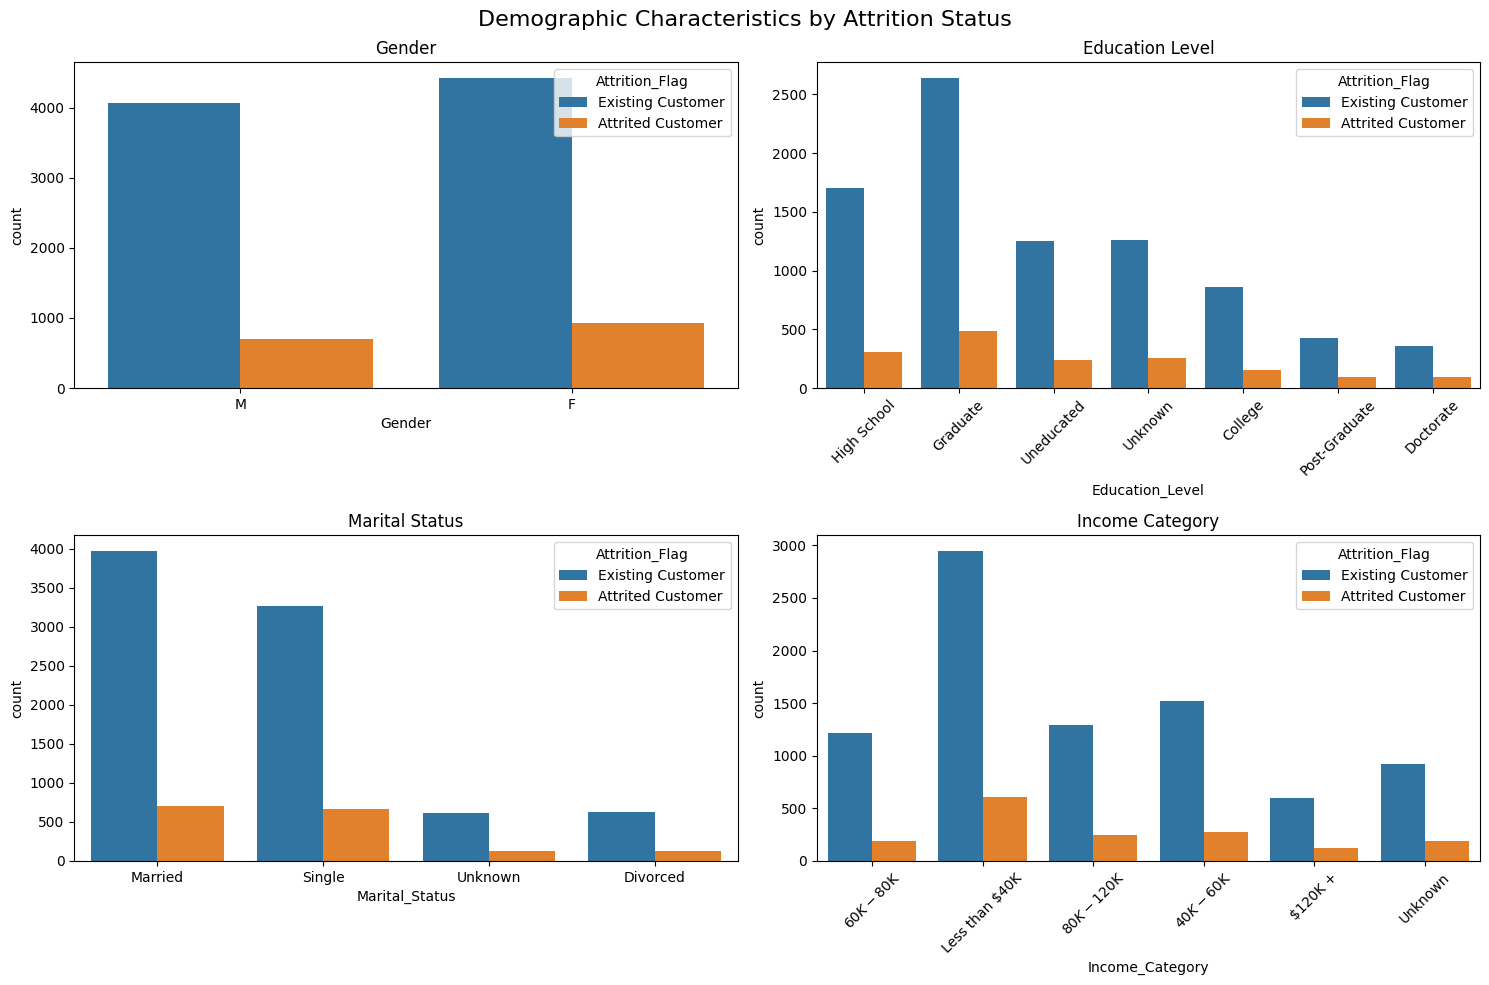

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.countplot(data=df, x='Gender', hue='Attrition_Flag', ax=axes[0,0])
axes[0,0].set_title('Gender')

sns.countplot(data=df, x='Education_Level', hue='Attrition_Flag', ax=axes[0,1])
axes[0,1].set_title('Education Level')
axes[0,1].tick_params(axis='x', rotation=45)

sns.countplot(data=df, x='Marital_Status', hue='Attrition_Flag', ax=axes[1,0])
axes[1,0].set_title('Marital Status')

sns.countplot(data=df, x='Income_Category', hue='Attrition_Flag', ax=axes[1,1])
axes[1,1].set_title('Income Category')
axes[1,1].tick_params(axis='x', rotation=45)

plt.suptitle('Demographic Characteristics by Attrition Status', fontsize=16)

plt.tight_layout()

plt.show()

En conjunto, las variables demográficas analizadas (género, nivel educativo, estado civil y categoría de ingresos) presentan distribuciones similares entre los clientes activos y aquellos que abandonaron el servicio. Aunque algunos grupos concentran un mayor número de abandonos, esto coincide con que también representan la mayor proporción de clientes en la muestra. Por lo tanto, a partir de estos gráficos no se observan diferencias suficientemente marcadas que indiquen que las características demográficas, por sí solas, sean los principales factores asociados con el abandono de clientes.

Estos resultados sugieren que las variables del uso de tarjeta de crédito  y de comportamiento probablemente tengan una mayor capacidad para explicar el abandono, aspecto que se analiza en las siguientes secciones del estudio.

Variables financieras:

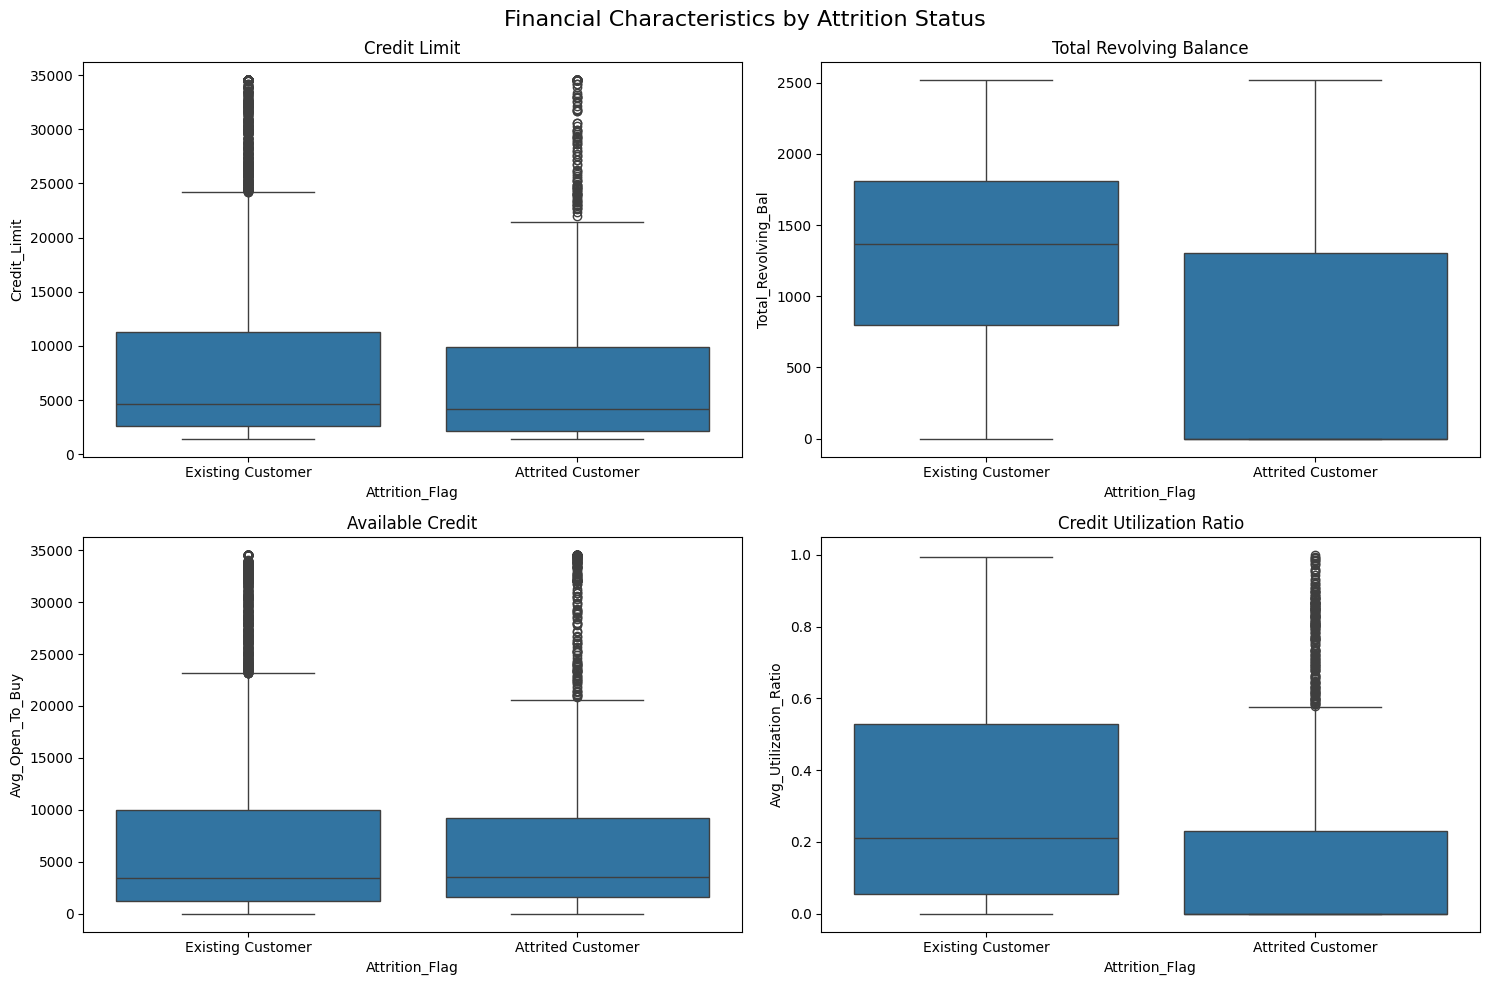

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.boxplot(data=df, x='Attrition_Flag', y='Credit_Limit', ax=axes[0,0])
axes[0,0].set_title('Credit Limit')

sns.boxplot(data=df, x='Attrition_Flag', y='Total_Revolving_Bal', ax=axes[0,1])
axes[0,1].set_title('Total Revolving Balance')

sns.boxplot(data=df, x='Attrition_Flag', y='Avg_Open_To_Buy', ax=axes[1,0])
axes[1,0].set_title('Available Credit')

sns.boxplot(data=df, x='Attrition_Flag', y='Avg_Utilization_Ratio', ax=axes[1,1])
axes[1,1].set_title('Credit Utilization Ratio')

plt.suptitle('Financial Characteristics by Attrition Status', fontsize=16)

plt.tight_layout()

plt.show()

En conjunto, los resultados muestran que las variables relacionadas con el uso del crédito presentan diferencias más claras que aquellas relacionadas con la capacidad crediticia. Mientras que el límite de crédito y el crédito disponible muestran distribuciones similares entre ambos grupos, por su parte, el saldo revolvente y el índice de utilización del crédito evidencian diferencias importantes.

En particular, los clientes que abandonaron el servicio tienden a mantener menores saldos pendientes y una menor utilización del crédito, lo que sugiere un uso menos frecuente de la tarjeta antes de cancelar el servicio. Estos hallazgos indican que el nivel de utilización de la tarjeta podría ser un indicador más relevante del riesgo de abandono que el monto del crédito otorgado por la institución financiera.

Variables de comportamiento:

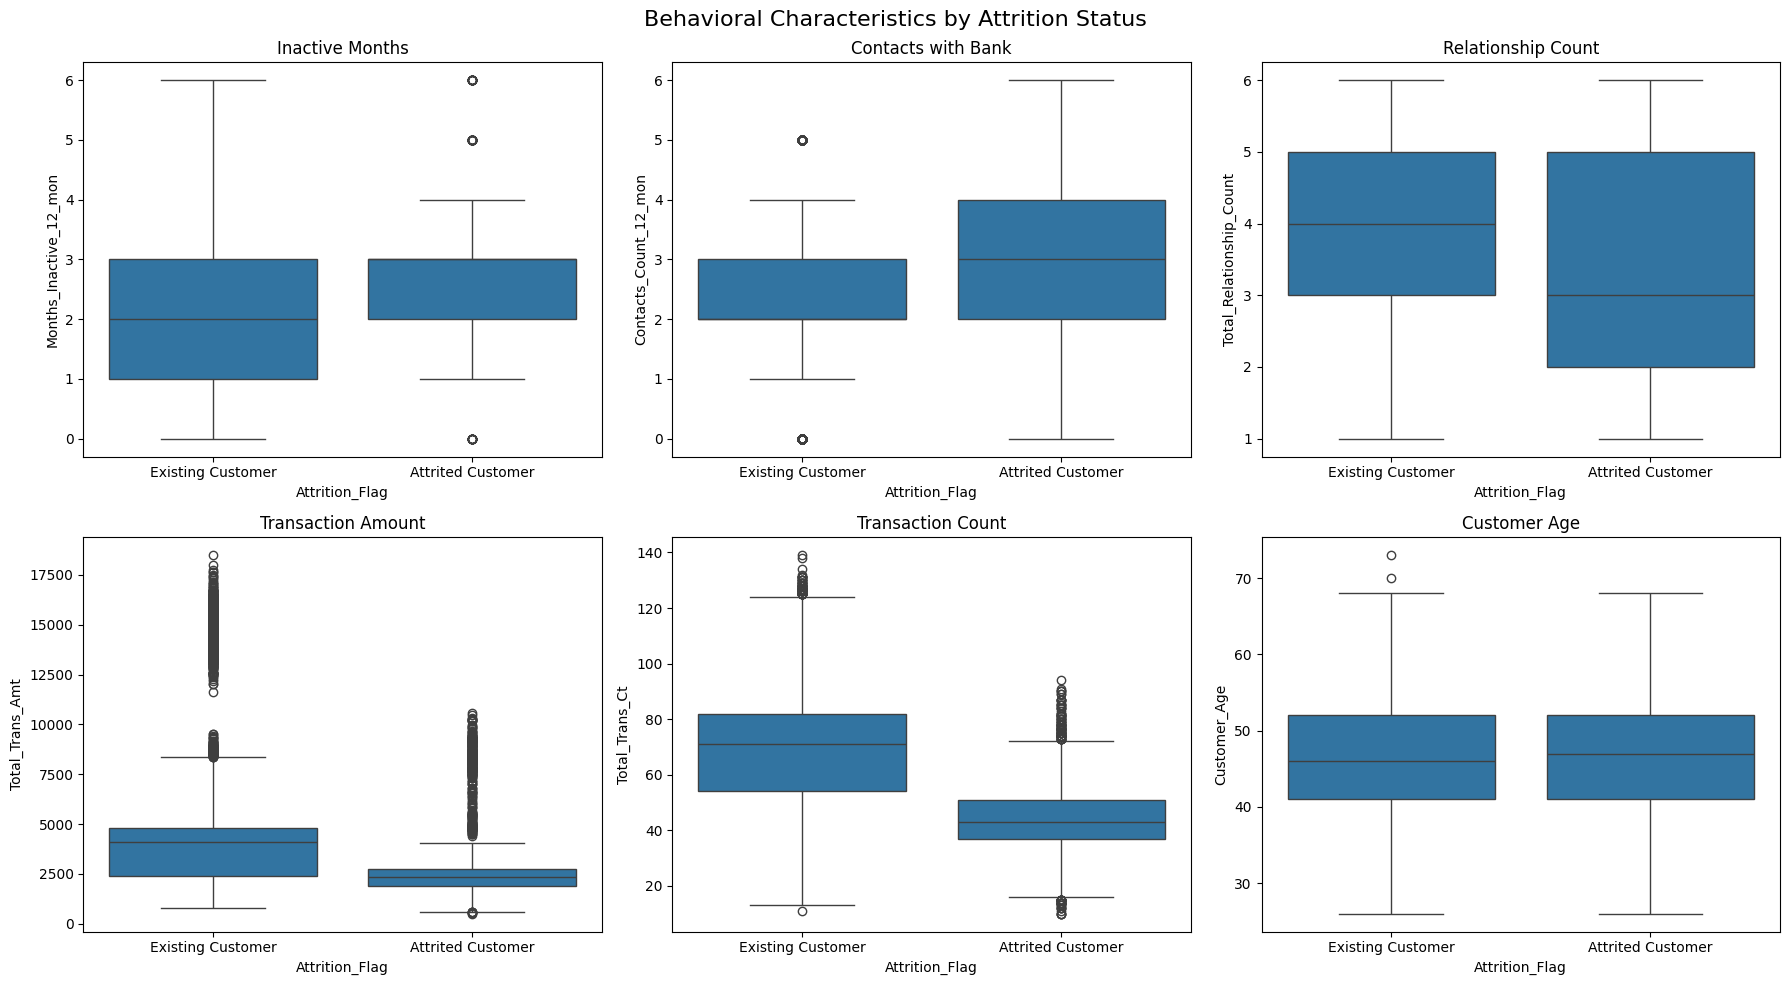

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

sns.boxplot(data=df,
            x='Attrition_Flag',
            y='Months_Inactive_12_mon',
            ax=axes[0,0])
axes[0,0].set_title('Inactive Months')

sns.boxplot(data=df,
            x='Attrition_Flag',
            y='Contacts_Count_12_mon',
            ax=axes[0,1])
axes[0,1].set_title('Contacts with Bank')

sns.boxplot(data=df,
            x='Attrition_Flag',
            y='Total_Relationship_Count',
            ax=axes[0,2])
axes[0,2].set_title('Relationship Count')

sns.boxplot(data=df,
            x='Attrition_Flag',
            y='Total_Trans_Amt',
            ax=axes[1,0])
axes[1,0].set_title('Transaction Amount')

sns.boxplot(data=df,
            x='Attrition_Flag',
            y='Total_Trans_Ct',
            ax=axes[1,1])
axes[1,1].set_title('Transaction Count')

sns.boxplot(data=df,
            x='Attrition_Flag',
            y='Customer_Age',
            ax=axes[1,2])
axes[1,2].set_title('Customer Age')

plt.suptitle('Behavioral Characteristics by Attrition Status', fontsize=16)

plt.tight_layout()

plt.show()

En conjunto, los resultados muestran que las variables de comportamiento presentan las diferencias más importantes entre los clientes activos y aquellos que abandonaron el servicio. En particular, el número de transacciones, el monto total de transacciones, los meses de inactividad y el número de productos financieros contratados destacan como las variables con mayor asociación al abandono.

Estos hallazgos indican que el comportamiento de uso de la tarjeta y el nivel de vinculación con el banco son factores mucho más relevantes para explicar el abandono que las características demográficas. En consecuencia, la institución financiera podría utilizar estas variables para identificar de manera temprana a los clientes con mayor riesgo de abandonar el servicio y desarrollar estrategias de retención más efectivas.

2. ¿Qué variables presentan mayor relación con el abandono de clientes?

Comparativa de las variables de comportamiento

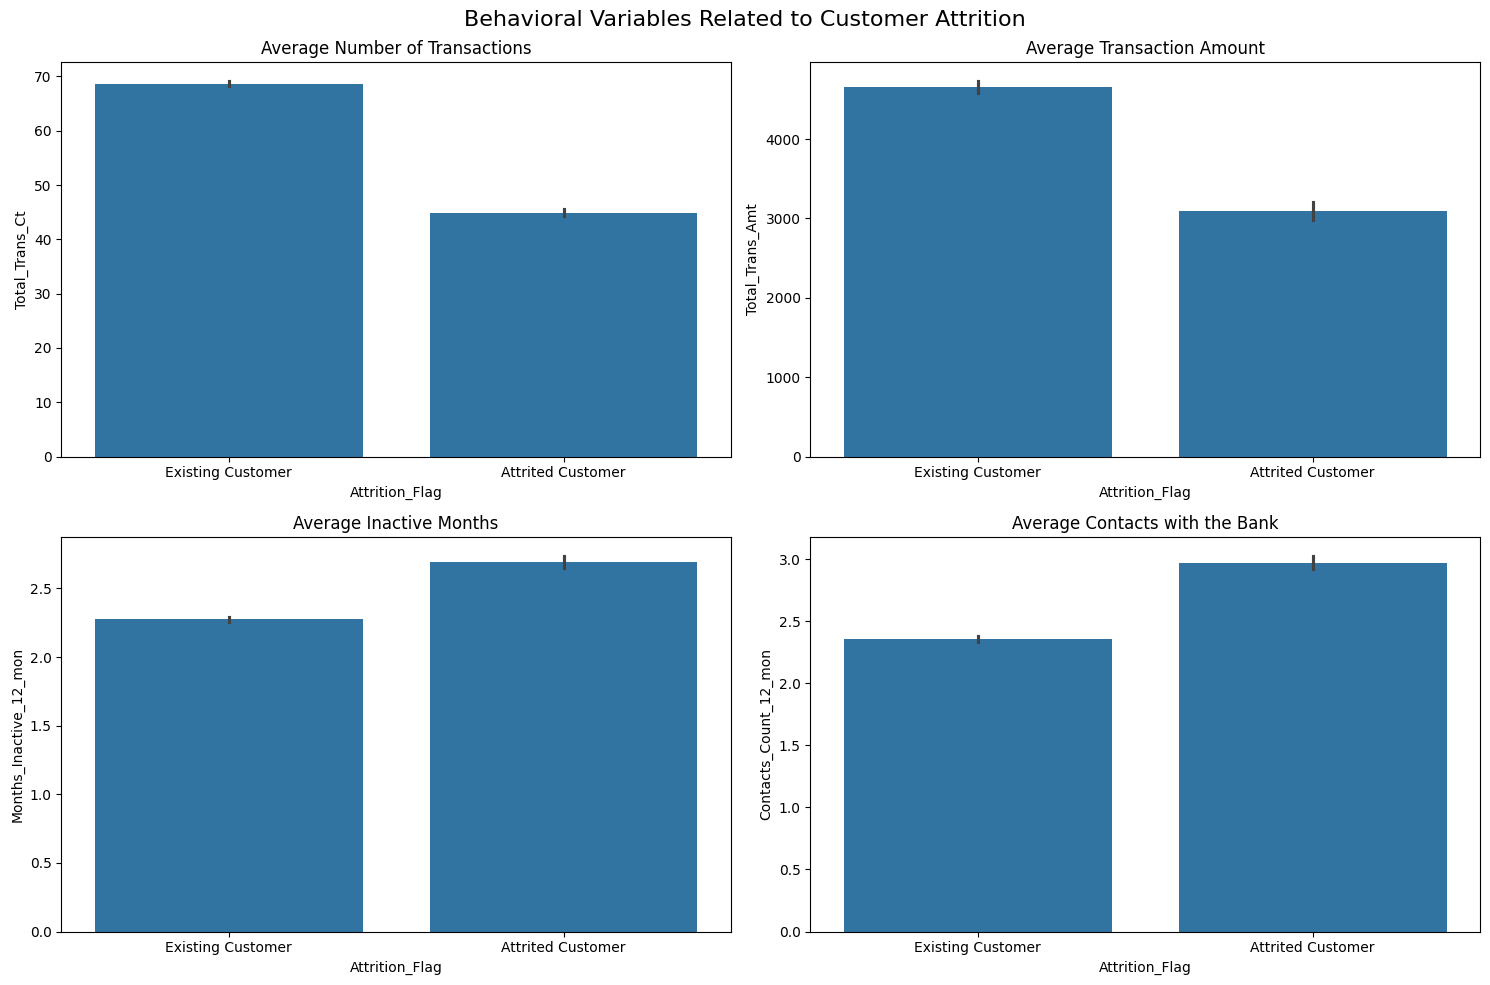

In [15]:
fig, axes = plt.subplots(2,2, figsize=(15,10))

sns.barplot(data=df,
            x='Attrition_Flag',
            y='Total_Trans_Ct',
            ax=axes[0,0])

axes[0,0].set_title('Average Number of Transactions')

sns.barplot(data=df,
            x='Attrition_Flag',
            y='Total_Trans_Amt',
            ax=axes[0,1])

axes[0,1].set_title('Average Transaction Amount')

sns.barplot(data=df,
            x='Attrition_Flag',
            y='Months_Inactive_12_mon',
            ax=axes[1,0])

axes[1,0].set_title('Average Inactive Months')

sns.barplot(data=df,
            x='Attrition_Flag',
            y='Contacts_Count_12_mon',
            ax=axes[1,1])

axes[1,1].set_title('Average Contacts with the Bank')

plt.suptitle('Behavioral Variables Related to Customer Attrition', fontsize=16)

plt.tight_layout()

plt.show()

Los resultados muestran que las variables relacionadas con el comportamiento de los clientes presentan diferencias claras entre los clientes activos y aquellos que abandonaron el servicio. En particular, el número de transacciones y el monto total de transacciones son considerablemente menores entre los clientes que abandonaron, mientras que los meses de inactividad y el número de contactos con el banco son superiores.

Estos hallazgos sugieren que la disminución en el uso de la tarjeta y el incremento en la inactividad constituyen señales tempranas de abandono, mientras que un mayor número de contactos con el banco podría indicar la existencia de problemas o necesidades no resueltas antes de que el cliente decida cancelar el servicio.

Comparativa de variables financieras:

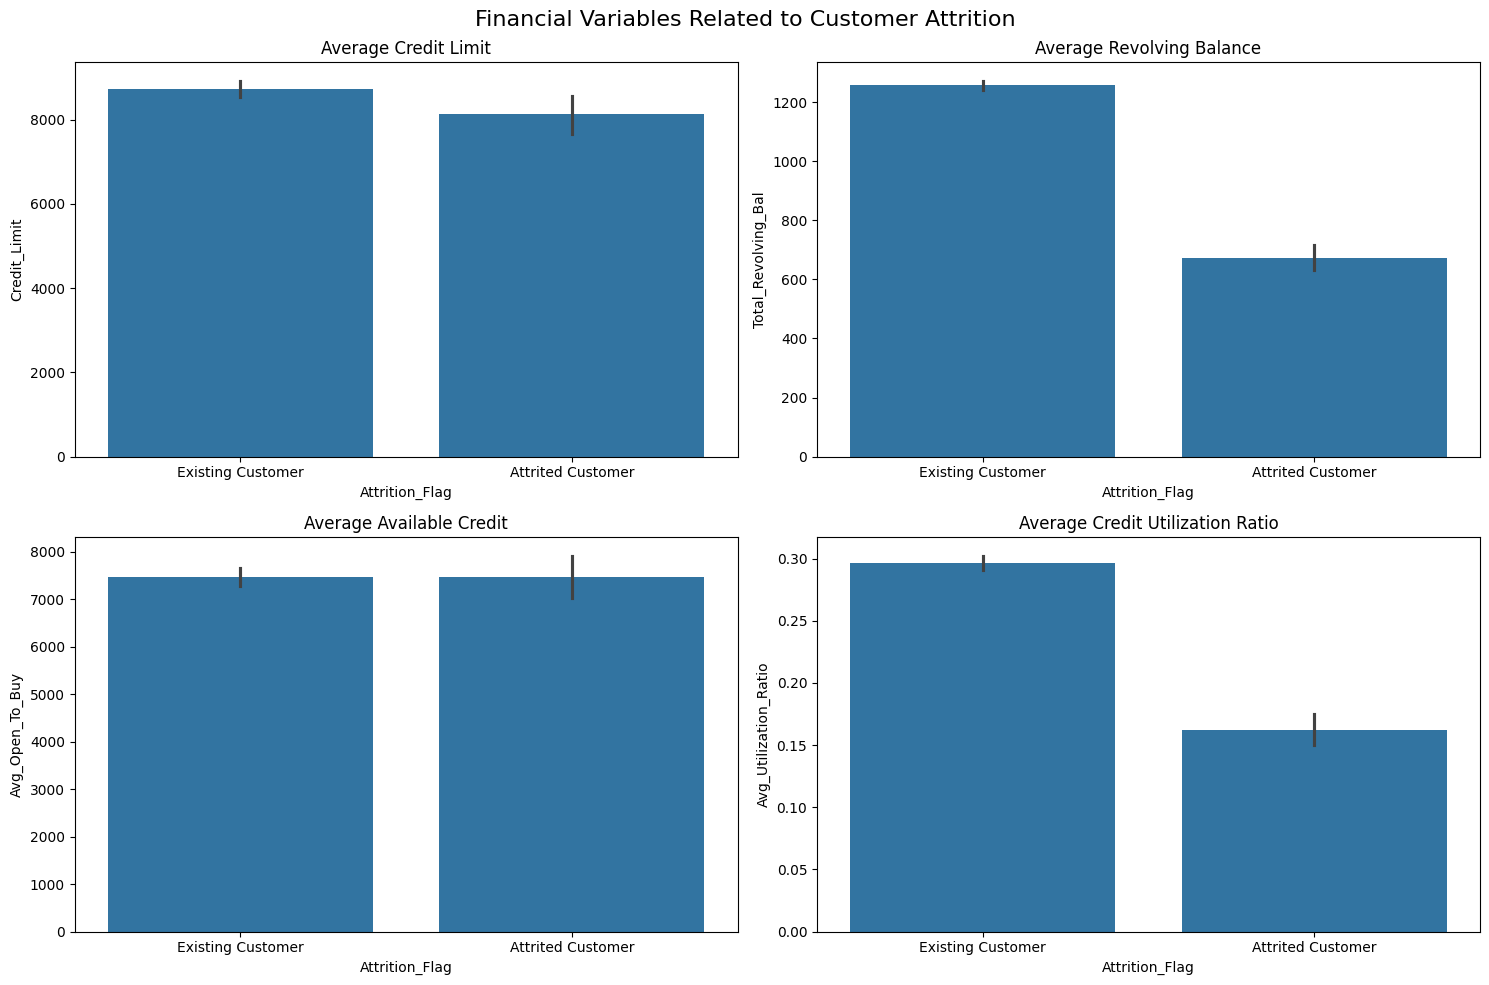

In [16]:
fig, axes = plt.subplots(2,2, figsize=(15,10))

sns.barplot(data=df,
            x='Attrition_Flag',
            y='Credit_Limit',
            ax=axes[0,0])

axes[0,0].set_title('Average Credit Limit')

sns.barplot(data=df,
            x='Attrition_Flag',
            y='Total_Revolving_Bal',
            ax=axes[0,1])

axes[0,1].set_title('Average Revolving Balance')

sns.barplot(data=df,
            x='Attrition_Flag',
            y='Avg_Open_To_Buy',
            ax=axes[1,0])

axes[1,0].set_title('Average Available Credit')

sns.barplot(data=df,
            x='Attrition_Flag',
            y='Avg_Utilization_Ratio',
            ax=axes[1,1])

axes[1,1].set_title('Average Credit Utilization Ratio')

plt.suptitle('Financial Variables Related to Customer Attrition', fontsize=16)

plt.tight_layout()

plt.show()

En conjunto, los resultados muestran que las variables relacionadas con el uso efectivo de la línea de crédito presentan diferencias más importantes que aquellas relacionadas con la capacidad crediticia otorgada por el banco.

Mientras que el límite de crédito y el crédito disponible son muy similares entre clientes activos y clientes que abandonaron, el saldo revolvente y el índice de utilización del crédito muestran diferencias claramente más marcadas.

Estos resultados sugieren que el nivel de uso de la tarjeta de crédito tiene una mayor relación con el abandono que el monto del crédito autorizado por el banco. En otras palabras, los clientes que dejan de utilizar activamente su línea de crédito presentan una mayor probabilidad de abandonar el servicio.

Comparativa relación cliente-banco:

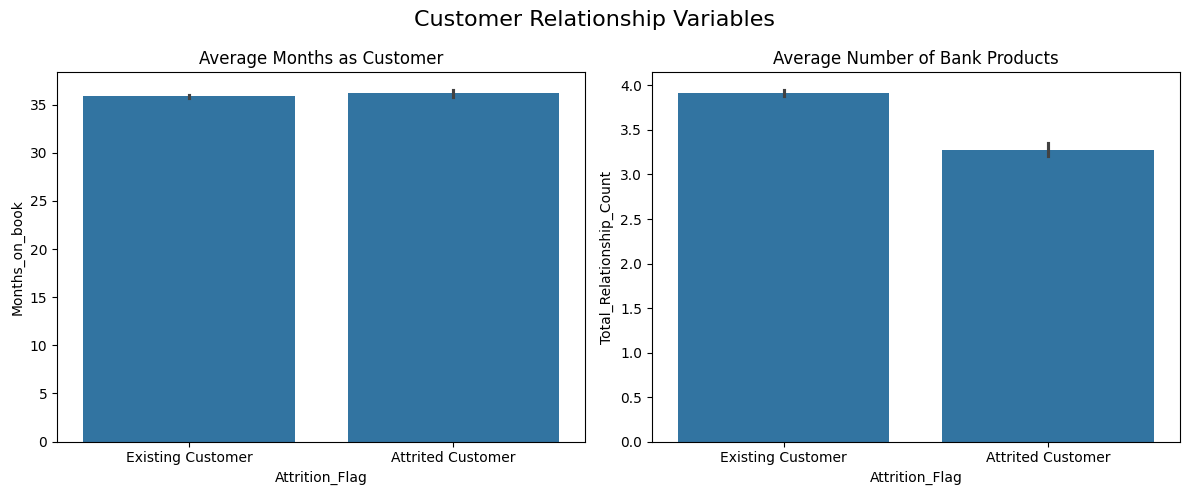

In [17]:
fig, axes = plt.subplots(1,2, figsize=(12,5))

sns.barplot(data=df,
            x='Attrition_Flag',
            y='Months_on_book',
            ax=axes[0])

axes[0].set_title('Average Months as Customer')

sns.barplot(data=df,
            x='Attrition_Flag',
            y='Total_Relationship_Count',
            ax=axes[1])

axes[1].set_title('Average Number of Bank Products')

plt.suptitle('Customer Relationship Variables', fontsize=16)

plt.tight_layout()

plt.show()

Los resultados indican que la antigüedad como cliente no parece ser un factor relevante para explicar el abandono, ya que ambos grupos presentan un tiempo promedio muy similar de permanencia en el banco.

En contraste, el número de productos financieros contratados sí muestra una diferencia importante. Los clientes activos mantienen una relación más amplia con la institución financiera, mientras que los clientes que abandonaron cuentan con un menor número de productos. Esto sugiere que una mayor diversificación de productos fortalece la relación entre el cliente y el banco, reduciendo la probabilidad de abandono.

Comparativa de la relación en el uso de la tarjeta:

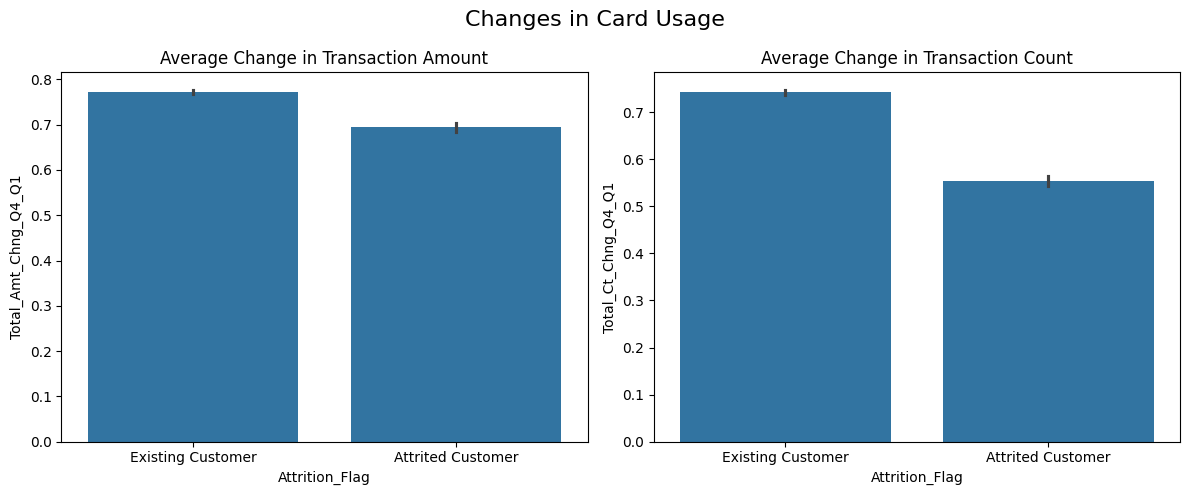

In [18]:
fig, axes = plt.subplots(1,2, figsize=(12,5))

sns.barplot(data=df,
            x='Attrition_Flag',
            y='Total_Amt_Chng_Q4_Q1',
            ax=axes[0])

axes[0].set_title('Average Change in Transaction Amount')

sns.barplot(data=df,
            x='Attrition_Flag',
            y='Total_Ct_Chng_Q4_Q1',
            ax=axes[1])

axes[1].set_title('Average Change in Transaction Count')

plt.suptitle('Changes in Card Usage', fontsize=16)

plt.tight_layout()

plt.show()

Los resultados muestran que los clientes que abandonaron el servicio presentan una reducción más pronunciada tanto en el monto como en la cantidad de transacciones entre el primer y el cuarto trimestre. Esto indica que, antes de cancelar la tarjeta, estos clientes tienden a disminuir gradualmente su nivel de actividad.

Asimismo, la diferencia observada en el cambio del número de transacciones es mayor que la observada en el cambio del monto de las transacciones, lo que sugiere que la frecuencia de uso de la tarjeta podría ser un indicador más sensible del riesgo de abandono.

3. ¿Qué segmentos de clientes presentan un mayor riesgo de abandono?


Con el objetivo de identificar los segmentos de clientes con mayor riesgo de abandono, los clientes fueron agrupados de acuerdo con características relevantes de su comportamiento y relación con el banco. A diferencia de una segmentación basada únicamente en criterios estadísticos, los grupos fueron definidos utilizando rangos con significado de negocio, lo que facilita la interpretación de los resultados y el desarrollo de estrategias de retención.

In [19]:
df[['Total_Trans_Ct',
    'Months_Inactive_12_mon',
    'Total_Relationship_Count',
    'Avg_Utilization_Ratio']].describe()

,Total_Trans_Ct,Months_Inactive_12_mon,Total_Relationship_Count,Avg_Utilization_Ratio
count,10127.000000,10127.000000,10127.000000,10127.000000
mean,64.858695,2.341167,3.812580,0.274894
std,23.472570,1.010622,1.554408,0.275691
min,10.000000,0.000000,1.000000,0.000000
25%,45.000000,2.000000,3.000000,0.023000
50%,67.000000,2.000000,4.000000,0.176000
75%,81.000000,3.000000,5.000000,0.503000
max,139.000000,6.000000,6.000000,0.999000


Segmentación por uso de la tarjeta

In [20]:
df['Usage_Level'] = pd.cut(
    df['Total_Trans_Ct'],
    bins=[0,40,80,150],
    labels=['Low','Medium','High']
)

In [21]:
usage = pd.crosstab(
    df['Usage_Level'],
    df['Attrition_Flag'],
    normalize='index'
)*100

usage

Attrition_Flag,Attrited Customer,Existing Customer
Usage_Level,,
Low,31.527348,68.472652
Medium,17.467636,82.532364
High,1.215686,98.784314


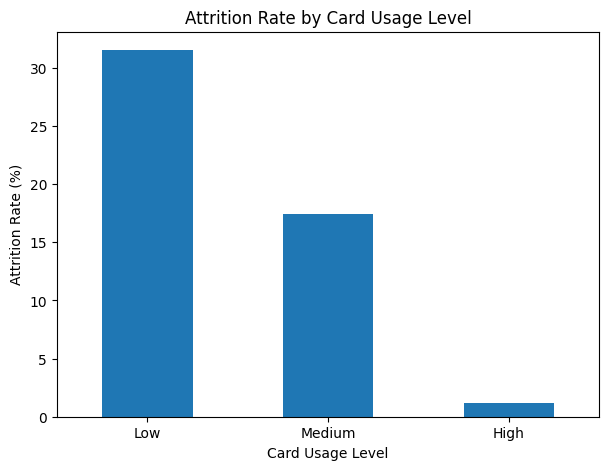

In [22]:
usage['Attrited Customer'].plot(
    kind='bar',
    figsize=(7,5)
)

plt.title('Attrition Rate by Card Usage Level')
plt.xlabel('Card Usage Level')
plt.ylabel('Attrition Rate (%)')

plt.xticks(rotation=360)

plt.show()

Los resultados sugieren que el nivel de uso de la tarjeta de crédito es uno de los factores más estrechamente relacionados con el abandono de clientes. Los clientes que utilizan la tarjeta con poca frecuencia presentan una probabilidad significativamente mayor de abandonar el servicio, mientras que aquellos que realizan un mayor número de transacciones tienden a mantenerse como clientes activos.

Este comportamiento refuerza los hallazgos obtenidos en los análisis anteriores, donde se observó que los clientes que abandonaron el servicio realizaban menos transacciones y registraban un menor monto total de compras.

Meses de inactividad

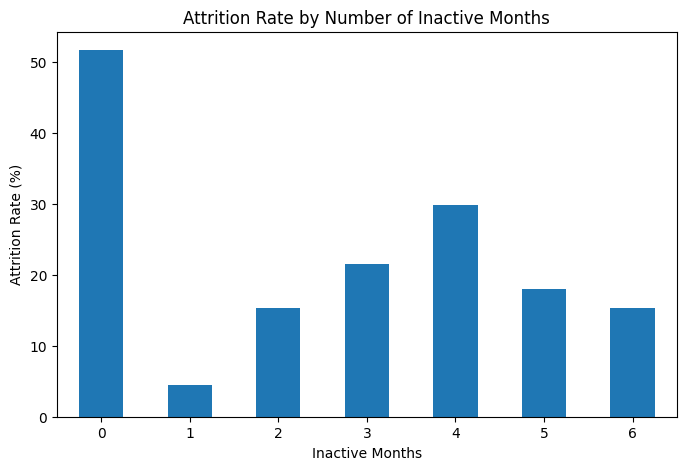

In [23]:
inactive = pd.crosstab(
    df['Months_Inactive_12_mon'],
    df['Attrition_Flag'],
    normalize='index'
) * 100

inactive['Attrited Customer'].plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Attrition Rate by Number of Inactive Months')
plt.xlabel('Inactive Months')
plt.ylabel('Attrition Rate (%)')

plt.xticks(rotation=360)

plt.show()

Aunque los clientes con 0 meses de inactividad presentan la tasa de abandono más alta, este grupo está conformado únicamente por 29 clientes, por lo que su porcentaje debe interpretarse con atención y tomando en cuenta este punto. Debido al reducido tamaño de la muestra, unos pocos casos de abandono tienen un impacto considerable en la tasa observada y no representan necesariamente el comportamiento general de la población.

Segmentación por número de productos

In [24]:
relationship = pd.crosstab(
    df['Total_Relationship_Count'],
    df['Attrition_Flag'],
    normalize='index'
)*100

relationship

Attrition_Flag,Attrited Customer,Existing Customer
Total_Relationship_Count,,
1,25.604396,74.395604
2,27.835881,72.164119
3,17.353579,82.646421
4,11.767782,88.232218
5,12.004231,87.995769
6,10.503751,89.496249


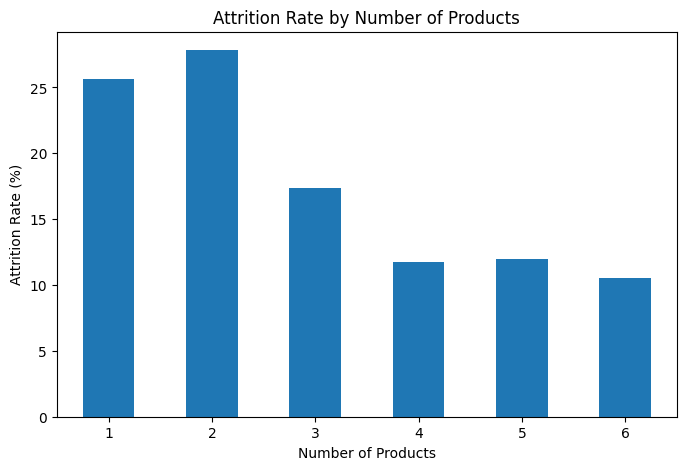

In [25]:
relationship['Attrited Customer'].plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Attrition Rate by Number of Products')
plt.xlabel('Number of Products')
plt.ylabel('Attrition Rate (%)')

plt.xticks(rotation=360)

plt.show()

Los resultados sugieren que el nivel de vinculación del cliente con el banco es un factor importante relacionado con el abandono. Los clientes que únicamente mantienen uno o dos productos financieros presentan una probabilidad significativamente mayor de cancelar el servicio, mientras que aquellos con una relación más amplia con la institución muestran una mayor permanencia.

Esto puede deberse a que los clientes con varios productos financieros generan una relación más sólida con el banco, lo que incrementa los costos o las dificultades de cambiar de institución y fortalece su fidelidad.

Segmentación por utilización del crédito

In [26]:
df['Utilization_Level'] = pd.cut(
    df['Avg_Utilization_Ratio'],
    bins=[0,0.30,0.70,1],
    labels=['Low','Medium','High'],
    include_lowest=True
)

In [27]:
utilization = pd.crosstab(
    df['Utilization_Level'],
    df['Attrition_Flag'],
    normalize='index'
)*100

utilization

Attrition_Flag,Attrited Customer,Existing Customer
Utilization_Level,,
Low,20.438190,79.561810
Medium,7.531083,92.468917
High,12.936733,87.063267


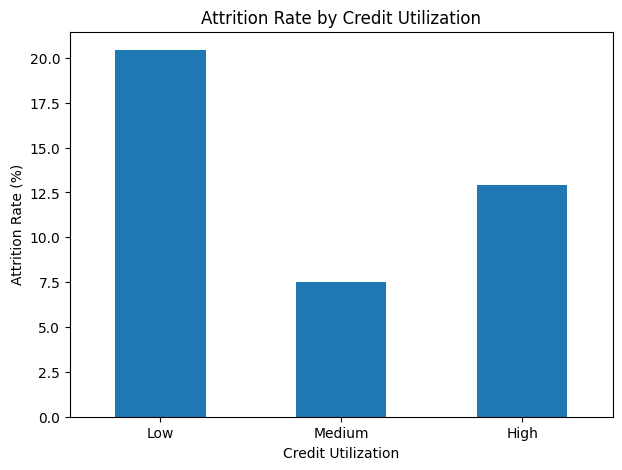

In [28]:
utilization['Attrited Customer'].plot(
    kind='bar',
    figsize=(7,5)
)

plt.title('Attrition Rate by Credit Utilization')
plt.xlabel('Credit Utilization')
plt.ylabel('Attrition Rate (%)')

plt.xticks(rotation=360)

plt.show()

El análisis sugiere que la utilización del crédito está relacionada con el abandono de clientes, aunque la relación no es completamente lineal. Los clientes con una utilización moderada muestran la mayor permanencia, mientras que aquellos con una utilización muy baja presentan el mayor riesgo de abandonar el servicio.

Este comportamiento podría indicar que los clientes que apenas utilizan su línea de crédito perciben un menor valor en el producto o han reducido progresivamente su actividad antes de cancelar la tarjeta.

# 5. Share

Tras analizar las características demográficas, financieras y de comportamiento de los clientes, así como los segmentos con mayor riesgo de abandono, se identificaron varios patrones que permiten comprender mejor los factores asociados con la pérdida de clientes. En esta sección se resumen los principales hallazgos obtenidos durante el análisis y se responden las preguntas de negocio planteadas al inicio del proyecto.

1. ¿Cuáles son las características de los clientes que abandonan el servicio de tarjeta de crédito?

- Utilizan la tarjeta con menor frecuencia.
- Realizan un menor monto de compras.
- Presentan más meses de inactividad.
- Mantienen menos productos financieros con el banco.
- Utilizan una menor proporción de su línea de crédito.
  
2. ¿Qué variables presentan mayor relación con el abandono de clientes?

Las variables con mayor relación fueron:

- Total_Trans_Ct
- Total_Trans_Amt
- Months_Inactive_12_mon
- Total_Relationship_Count
- Avg_Utilization_Ratio
- Total_Revolving_Bal

3. ¿Qué segmentos presentan mayor riesgo de abandono?

Los segmentos identificados fueron:

- Clientes con bajo uso de la tarjeta.
- Clientes con uno o dos productos financieros.
- Clientes con baja utilización del crédito.
- Clientes con mayor número de meses de inactividad.

4. ¿Qué estrategias pueden implementarse?

A partir de estos resultados es posible proponer diversas estrategias orientadas a incrementar el uso de la tarjeta de crédito, fortalecer la relación entre los clientes y el banco e identificar oportunamente a los clientes con mayor riesgo de abandono. Estas recomendaciones se presentan con mayor detalle en la siguiente fase del proceso (Act).

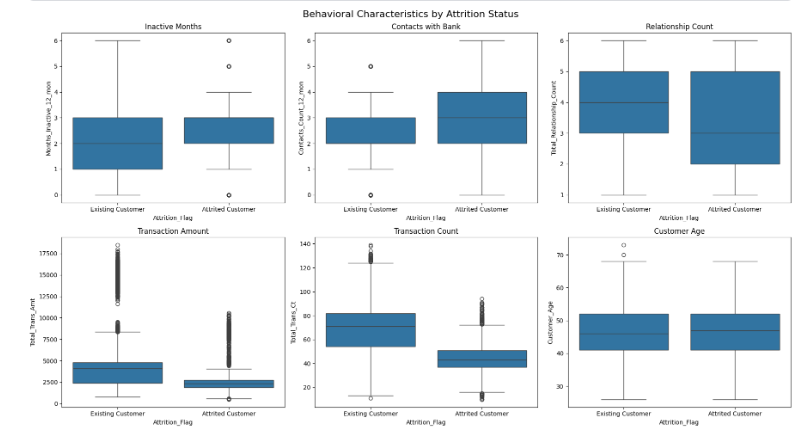

# 6. Act

A partir de los hallazgos obtenidos durante el análisis, se proponen una serie de recomendaciones orientadas a reducir la tasa de abandono de clientes y fortalecer la relación entre los clientes y la institución financiera. Estas acciones se enfocan en intervenir de manera temprana sobre los segmentos con mayor riesgo de abandono identificados en el estudio.

1. Implementar un sistema de alerta temprana para clientes en riesgo

Los resultados del análisis muestran que los clientes que presentan un menor número de transacciones, un menor monto de compras y un mayor número de meses de inactividad tienen una mayor probabilidad de abandonar el servicio. Con base en estos hallazgos, se recomienda implementar un sistema de monitoreo que identifique automáticamente a los clientes cuyo nivel de actividad disminuya de manera significativa. Este sistema permitiría detectar señales tempranas de abandono y activar acciones preventivas, como el envío de promociones personalizadas o el contacto directo con el cliente, antes de que decida cancelar su tarjeta de crédito.

2. Diseñar campañas para incentivar el uso de la tarjeta de crédito

El análisis evidenció que los clientes con un bajo nivel de uso de la tarjeta presentan la mayor tasa de abandono. Por ello, se recomienda desarrollar campañas de marketing dirigidas específicamente a este segmento, ofreciendo incentivos como programas de recompensas, devolución de efectivo (cashback), descuentos en establecimientos participantes o promociones especiales por el uso frecuente de la tarjeta. Estas estrategias pueden incrementar la frecuencia de uso del producto, fortalecer el vínculo entre el cliente y la institución financiera y reducir la probabilidad de abandono.

3. Fortalecer la relación con los clientes mediante la venta cruzada de productos

Los resultados muestran que los clientes con uno o dos productos financieros presentan una tasa de abandono significativamente mayor que aquellos con una mayor cantidad de productos contratados. En consecuencia, se recomienda implementar estrategias de venta cruzada (cross-selling) que incentiven a estos clientes a contratar productos adicionales, como cuentas de ahorro, préstamos personales, seguros o productos de inversión. Una mayor diversificación de la relación con el banco puede incrementar el compromiso del cliente con la institución y contribuir a mejorar su fidelización y permanencia a largo plazo.